<a href="https://colab.research.google.com/github/hindxb/FDS_Group_4/blob/main/Notebooks/Class%20Activities/Group_4_Gapminder_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**In-Class Team-Based Learning Activity** : Exploring Global Health & Wealth with Gapminder Data **[15 MARKS]**

---

## Objective

In this activity you will work in teams to explore **global health and economic data**.

You will work with **two separate Gapminder CSV datasets** that share a common key (`country`) and must be **joined (merged by column)** to answer meaningful questions about the relationship between wealth, health, and population.

### Datasets

Download the datasets from the Blackboard:

| File | Description |
|------|-------------|
| `Gapminder_Health.csv` | Country, Year, Continent, Life expectancy, Population |
| `gapminder_economy.csv` | Country, Year, GDP per capita |

> **Note :** Both datasets contain one row per (country, year) pair. They share `country` and `year` columns but carry **different** variables — you must **join them on `country`** to get a combined view.

### Key Columns After Joining

| Column | Dataset | Description |
|--------|---------|-------------|
| `country` | both (join key) | Country name |
| `continent` | health | Geographic region |
| `year` | both | 5-year interval (1952–2007) |
| `lifeExp` | health | Life expectancy at birth (years) |
| `pop` | health | Population |
| `gdpPercap` | economy | GDP per capita (USD, inflation-adjusted) |

### You will:
1. Load and **join (merge by columns)** the two datasets on `country`
2. **Explore** the joined data using Table methods
3. **Visualise** patterns with Table-based plots
4. **Define and use functions** with `.apply()`



## Setup – Install & Import

In [1]:
# Import the datascience library so we can work with tables and visualizations
!pip install datascience

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 725.1/725.1 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 50.7 MB/s eta 0:00:00


In [2]:
# Load all the libraries we need for this project:
# - datascience: makes it easy to work with tables and data
from datascience import *
# - numpy: gives us access to arrays and math functions like sin, cos, and pi
import numpy as np
# - matplotlib: for creating plots, displayed inline in the notebook
%matplotlib inline
import matplotlib.pyplot as plots
# We also set a clean plotting style and print a confirmation to know everything worked
plots.style.use('fivethirtyeight')
print('Libraries loaded successfully!')

Libraries loaded successfully!


---

## Task 1 — Load and Join the Datasets **[2 marks]**

**Goal :** Load each CSV file into its own `Table`, then use `.join()` to merge them by the shared key `country`.

The `datascience` library's `.join()` works like a database inner join:

```python
merged = table_A.join('shared_column', table_B)
```

### Step 1.1 – Download and load the health dataset

In [3]:
from google.colab import files

In [4]:
# Load the Gapminder Health dataset and assign it to 'health' table variable
uploaded = files.upload()
health = Table.read_table('Gapminder_Health.csv')

# Show the first 5 records
health.show(5)

# Show the number of columns and number of rows
print("the number of columns are", health.num_columns)
print("the number of rows are", health.num_rows)




Saving Gapminder_Health.csv to Gapminder_Health.csv


country,year,continent,lifeExp,pop
Afghanistan,1952,Asia,28.801,8.42533e+06
Afghanistan,1957,Asia,30.332,9.24093e+06
Afghanistan,1962,Asia,31.997,1.02671e+07
Afghanistan,1967,Asia,34.02,1.1538e+07
Afghanistan,1972,Asia,36.088,1.30795e+07


the number of columns are 5
the number of rows are 1704


### Step 1.2 – Load the economy dataset

In [5]:
# Load the Gapminder Economy dataset and assign it to 'economy' table variable
economy = files.upload()
economy = Table.read_table('Gapminder_Economy.csv')

# Show the first 5 records
economy.show(5)

# Show the number of columns and number of rows
print("the number of columns are", economy.num_columns)
print("the number of rows are", economy.num_rows)


Saving Gapminder_Economy.csv to Gapminder_Economy.csv


country,year,gdpPercap
Afghanistan,1952,779.445
Afghanistan,1957,820.853
Afghanistan,1962,853.101
Afghanistan,1967,836.197
Afghanistan,1972,739.981


the number of columns are 3
the number of rows are 1632


### Step 1.3 – Filter both tables to the **same year** before joining

Because each country appears multiple times (once per year), first filter to a single year so each country appears exactly once — making the join unambiguous.

> Use **year 2007** (the most recent in the dataset).


In [6]:
# Keep only 2007 records in two datasets and assign them to new Tables
health_2007 = health.where('year', are.equal_to(2007))
economy_2007 = economy.where('year', are.equal_to(2007))

# Display how many countries there are in two new tables: health_2007 and economy_2007
print("the number of countries in health_2007 is", health_2007.num_rows)
print("the number of countries in economy_2007 is", economy_2007.num_rows)




the number of countries in health_2007 is 142
the number of countries in economy_2007 is 136


### Step 1.4 – Join the two tables on `country`

In [7]:
# Join health data with economy data on 'country'
country_joined = health_2007.join('country', economy_2007, 'country')
# Display the first 5 records
country_joined.show(5)

# health_2007 has: country, continent, year, lifeExp, pop
# economy_2007 has: country, year, gdpPercap
# country_joined: has  country, year , continent, lifeExp, pop, year_2 (from the second table), gdpPercap

print("the number of rows in the joined table is",country_joined.num_rows)
print("the number of columns in the joined table is",country_joined.num_columns)




country,year,continent,lifeExp,pop,year_2,gdpPercap
Afghanistan,2007,Asia,43.828,3.18899e+07,2007,974.58
Albania,2007,Europe,76.423,3.60052e+06,2007,5937.03
Algeria,2007,Africa,72.301,3.33332e+07,2007,6223.37
Angola,2007,Africa,42.731,1.24205e+07,2007,4797.23
Argentina,2007,Americas,75.32,4.03019e+07,2007,12779.4


the number of rows in the joined table is 136
the number of columns in the joined table is 7


**✏️ Question 1.1 :** How many columns does the joined table have? Explain the columns in the joined table.









The Joined table has '7' columns, this is because the economy table has 3 columns (one of them is country) and the health table has 5 columns (one of them is country). Being joined on "country" makes it appear only once, and the other columns left are shows in the table which brings the total to 7.
- country: the column we joined on, displays the country which the information is about
- year: comes from the health_2007 table, is set to 2007 because we filtered it that way
- continent: comes from the health_2007 table, shows which continent the country is from
- lifeExp: comes from the health_2007 table, shows us the life expectancy in the country
- pop: comes from the health_2007 table, shows us the population in the country
- year_2: comes from the economy_2007 table, is set to 2007 because we filtered it that way, it appears as year'_2' because the first table had the same column already
- gdpPercap: comes from the economy_2007 table, shows the Gross Domestic Product (GDP) divided by the population

**✏️ Question 1.2 :** What would happen if we joined without filtering to a single year first? Why?

If we only join on country without filtering the year we will be creating a  cartesian-like explosion within each country which causes wrong duplicate data as data from Afghanistan from the year 1972 will be group with every other year of the data from Afghanistan in the second table. Every row from table 1 will match every row from table 2 for that specific country. As a example, in table one Afghanistan appears 12 times with different years and in table 2 it appears also 12 times with different years. For Afghanistan alone, we will have 12 x 12 = 144 rows. This is repeated for every other country.
why? because country is not a unique key and each country appears many times once a year in each table so we cant uniquely match the rows with join without filtering

---

## Task 2 — Explore the Joined Data Using Tables **[3 marks]**

**Goal :** Use `.select()`, `.where()`, `.group()`, and `.sort()` to extract insights.

### Step 2.1 – Select relevant columns


In [8]:
# Keep the columns in world we care about and give them clean names
# They are 'country', 'continent', 'lifeExp', 'pop', 'gdpPercap'
world = country_joined.select('country', 'continent', 'lifeExp', 'pop', 'gdpPercap')

# show the first 5 records
world.show(5)




country,continent,lifeExp,pop,gdpPercap
Afghanistan,Asia,43.828,3.18899e+07,974.58
Albania,Europe,76.423,3.60052e+06,5937.03
Algeria,Africa,72.301,3.33332e+07,6223.37
Angola,Africa,42.731,1.24205e+07,4797.23
Argentina,Americas,75.32,4.03019e+07,12779.4


### Step 2.2 – Filter rows

In [9]:
# Create a new table, high_life, containing the countries with life expectancy above 80 years
high_life = world.where('lifeExp', are.above(80))
# Display them
high_life.show()
print("the countries with life expectancy above 80 years are", high_life.column('country'))





country,continent,lifeExp,pop,gdpPercap
Australia,Oceania,81.235,2.04342e+07,34435.4
Canada,Americas,80.653,3.33901e+07,36319.2
France,Europe,80.657,6.10839e+07,30470
Iceland,Europe,81.757,301931,36180.8
Israel,Asia,80.745,6.42668e+06,25523.3
Italy,Europe,80.546,5.81477e+07,28569.7
Japan,Asia,82.603,1.27468e+08,31656.1
New Zealand,Oceania,80.204,4.11577e+06,25185
Norway,Europe,80.196,4.62793e+06,49357.2
Spain,Europe,80.941,4.04482e+07,28821.1


the countries with life expectancy above 80 years are ['Australia' 'Canada' 'France' 'Iceland' 'Israel' 'Italy' 'Japan'
 'New Zealand' 'Norway' 'Spain' 'Sweden' 'Switzerland']


In [10]:
# Create a new table, asia, containing the countries in Asia only
asia = world.where('continent', are.equal_to('Asia'))

# Display how many countries in Asia
print("the number of countries in Asia is", asia.num_rows)

# Sort the countries in alphabetic order and show the first 10 of them
asia.sort('country').show(10)




the number of countries in Asia is 29


country,continent,lifeExp,pop,gdpPercap
Afghanistan,Asia,43.828,3.18899e+07,974.58
Bahrain,Asia,75.635,708573,29796
Bangladesh,Asia,64.062,1.50448e+08,1391.25
Cambodia,Asia,59.723,1.41319e+07,1713.78
China,Asia,72.961,1.31868e+09,4959.11
India,Asia,64.698,1.1104e+09,2452.21
Indonesia,Asia,70.65,2.23547e+08,3540.65
Iran,Asia,70.964,6.94536e+07,11605.7
Iraq,Asia,59.545,2.74996e+07,4471.06
Israel,Asia,80.745,6.42668e+06,25523.3


### Step 2.3 – Summarise data

In [11]:
# Calculate the Average life expectancy per continent
averaged_continents= world.group('continent',np.average)
# and show them in descending order.
averaged_continents.select('continent','lifeExp average').sort('lifeExp average', descending=True).show()





continent,lifeExp average
Oceania,80.7195
Europe,77.6486
Americas,73.6081
Asia,70.4557
Africa,54.9626


In [12]:
# Calculate the Average GDP per capita per continent
averaged_GPD= world.group('continent',np.average)
# and display them in ascending order
averaged_GPD.select('continent','gdpPercap average').sort('gdpPercap average').show()




continent,gdpPercap average
Africa,3134.39
Americas,11003
Asia,11884.9
Europe,25054.5
Oceania,29810.2


**✏️ Question 2.1 :** Which continent has the highest average life expectancy in 2007? Which has the lowest?




In [13]:
#we group by countries and average all values
average_life_exp_country = world.group('country',np.average)

#show only the highest country
print("the country with the highest average life expectancy is")
average_life_exp_country.select('country','lifeExp average').sort('lifeExp average', descending=True).show(1)

#show only the lowest country
print("the country with the lowest average life expectancy is")
average_life_exp_country.select('country','lifeExp average').sort('lifeExp average').show(1)

the country with the highest average life expectancy is


country,lifeExp average
Japan,82.603


the country with the lowest average life expectancy is


country,lifeExp average
Swaziland,39.613


The country with the highest life expectancy is Japan (82) and the country with the lowest life expectancy is swaziland (39)

**✏️ Question 2.2 :** Write code to find the **top 5 countries by GDP per capita** in the dataset. Are any of them surprising?



In [14]:

#sorts in descending order to get the highest on top and selects relevnt columns
top5_gdp = world.sort('gdpPercap', descending=True).select('country', 'continent', 'gdpPercap')
#shows top 5
top5_gdp.show(5)


country,continent,gdpPercap
Norway,Europe,49357.2
Kuwait,Asia,47307
Singapore,Asia,47143.2
United States,Americas,42951.7
Ireland,Europe,40676


Yes it is a bit surprising that smaller countries like Kuwait and Singapore are in the top list with larger economies like the US. This indicates that GDP per capita is influenced by factors other than total economic strength, such as population size and wealth distribution.

---

## Task 3 — Visualise the Data Using Table-Based Plots **[5 marks]**

**Goal :** Use `.barh()`, `.hist()`, and `.scatter()` to reveal patterns.

### Step 3.1 – Bar chart: average life expectancy by continent


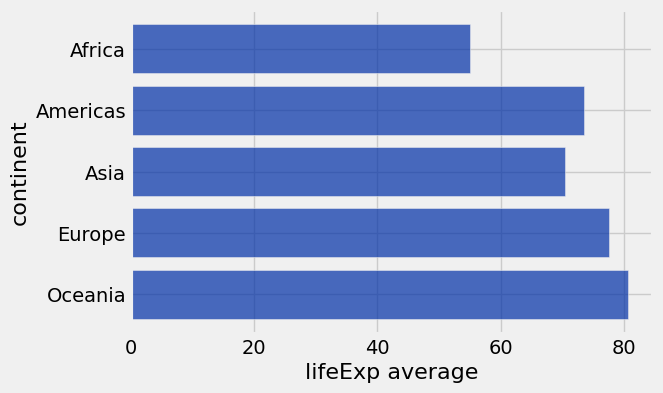

In [15]:
# Show the Average Life Expectancy by Continent (2007) using barh graphic
average_life_exp = world.group('continent',np.average)
#choose the display axis
average_life_exp.barh('continent', 'lifeExp average')








### Step 3.2 – Histogram: distribution of GDP per capita

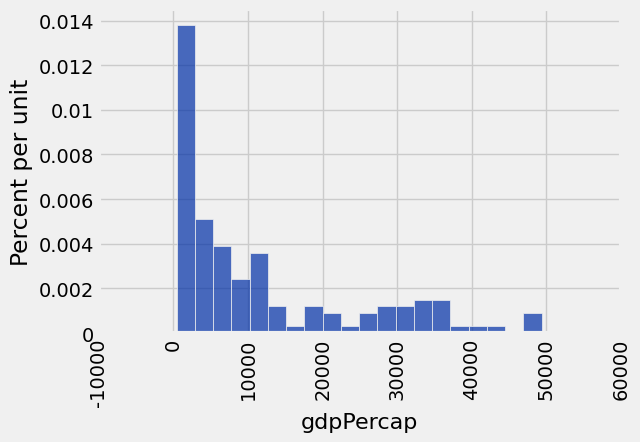

In [16]:
# Show the Distribution of GDP per Capita Across Countries (2007) using a histogram with 20 bins
world.hist('gdpPercap', bins=20)




### Step 3.3 – Scatter plot: GDP per capita vs. life expectancy

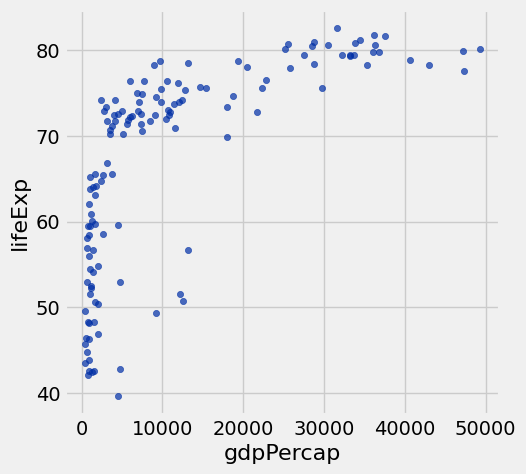

In [17]:
# Show GDP per Capita vs. Life Expectancy (2007) using a Scatter plot.
world.scatter('gdpPercap', 'lifeExp')




**✏️ Question 3.1 :** Describe the relationship between GDP per capita and life expectancy. Is it linear or non-linear? What does this suggest?






The relationship between GDP per capita and life expectancy is positive, when GDP per capita increases then life expectancy also increases. it is not linear as the relationship is curved and it does not show that the relationship can be fitted with a straight line. There are big improvements in life expectancy at low GDP level and small increase at high GDP levels.
This suggests that the initial increases in income can improve healthcare, nutrition, and living conditions but after a certain point the wealth has limited impact on life expectancy.

**✏️ Question 3.2 (Challenge) :** Create a bar chart showing the **5 countries with the lowest life expectancy**. What continent are most of them on?


country,continent,lifeExp
Swaziland,Africa,39.613
Mozambique,Africa,42.082
Zambia,Africa,42.384
Sierra Leone,Africa,42.568
Lesotho,Africa,42.592


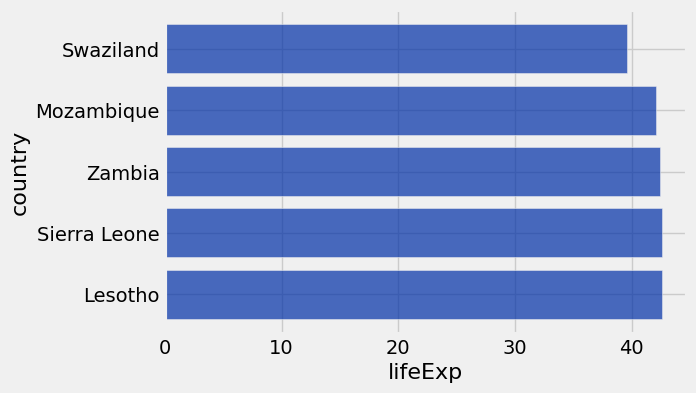

In [18]:
#Sort by lowest life expectancy and take bottom 5 countries
lowest_5 = world.sort('lifeExp').take(np.arange(5))
#plot the bar chart
lowest_5.barh('country', 'lifeExp')
#what continents are they from?
lowest_5.select('country', 'continent', 'lifeExp').show()


the countries with the lowest life expectancies are all from Africa

---

## Task 4 — Define and Use Functions with Tables **[5 marks]**

**Goal :** Write Python functions and apply them to table columns.

### Step 4.1 – Classify countries by income level

The World Bank uses GDP per capita thresholds to classify countries. The following defines a simplified version
and will be used to develop the function:

| Category | GDP per capita (USD) |  String to be returned |
|----------|----------------------|------------------------|
| Low income | < 1 000 |          'Low income'           |
| Lower-middle income | 1 000 – 3 999 | 'Lower-middle income'   |
| Upper-middle income | 4 000 – 12 999 | 'Upper-middle income' |
| High income | ≥ 13 000 | 'High income' |


In [19]:
# Implement income_group function
# It returns a World-Bank-style income classification based on GDP per capita.
def income_group(gdp):
  if gdp < 1000:
    return 'Low income'
  elif gdp >= 1000 and gdp < 4000:
    return 'Lower-middle income'
  elif gdp >= 4000 and gdp < 13000:
    return 'Upper-middle income'
  return 'High income'

# Quick test for your function
print(income_group(500))    # Low income
print(income_group(2500))   # Lower-middle income
print(income_group(8000))   # Upper-middle income
print(income_group(40000))  # High income


Low income
Lower-middle income
Upper-middle income
High income


In [20]:
# Apply the function to the gdpPercap column
world_with_income = world.with_column('income', world.apply(income_group, 'gdpPercap'))
# Display the first 5 records
world_with_income.show(5)




country,continent,lifeExp,pop,gdpPercap,income
Afghanistan,Asia,43.828,3.18899e+07,974.58,Low income
Albania,Europe,76.423,3.60052e+06,5937.03,Upper-middle income
Algeria,Africa,72.301,3.33332e+07,6223.37,Upper-middle income
Angola,Africa,42.731,1.24205e+07,4797.23,Upper-middle income
Argentina,Americas,75.32,4.03019e+07,12779.4,Upper-middle income


In [21]:
# How many countries in each income group?
world_with_income.group('income')


income,count
High income,39
Low income,19
Lower-middle income,35
Upper-middle income,43


---

## Grading Distribution (Out of 25)

| Task | Description | Marks |
|------|-------------|-------|
| 1 | Load and join datasets with `.join()` | 2 |
| 2 | Explore with `.select()`, `.where()`, `.group()` | 3 |
| 3 | Visualise with `.barh()`, `.hist()`, `.scatter()` | 5 |
| 4 | Functions & `.apply()` | 5 |
| **Total** | | **15** |


## Submission Instructions

- **1. File Requirements**
  - **File Name :** Save your notebook as `Group_No_Gapminder_Analysis.ipynb`. Replace `Group_No` with your assigned group number.
  - **Self-Contained :** Run all cells before submitting. Include all outputs and Markdown explanations.
  - **Colab Compatibility :** Test that the notebook opens and runs via "Open in Colab":

    [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/your_username/your_repo/blob/main/Group_No_Gapminder_Analysis.ipynb)

    Replace `your_username`, `your_repo`, and `Group_No` with your actual Github username, repository name, and group no, accordingly.

- **2. Group Information**
  Include the group number and all member names at the bottom of this text block.

- **3. Submission Process**
  - **GitHub :** Upload the completed notebook to a public repository with a `README.md`.
  - **Blackboard :** Submit the GitHub link **and** upload the `.ipynb` file as backup.


# Group No: [4]
## Members:
- Hind Alzarooni  U25102248
- Arwa Alzaabi  U24200509
- Aisha Mahmoud U25100400
- Lojaen Alkaddah U25200327
- Fatima Alblooshi  U25200290